# Task
Analyze household power consumption data from "household_power_consumption.xls" by performing data preprocessing, feature engineering, unsupervised clustering to identify consumption patterns, and then training cluster-specific supervised models (RandomForestRegressor and XGBoostRegressor) for time series forecasting. Finally, visualize the results and summarize key findings.

## Load and Preprocess Data

### Subtask:
Load the household power consumption data, combine date and time information, convert relevant columns to numeric, handle missing values, and resample the data to an hourly frequency.


**Reasoning**:
The previous attempt to load the data failed because it tried to read an Excel file as a CSV and used an incorrect file path. I will correct this by using `pd.read_excel` with the correct file name and proceed with the remaining preprocessing steps as outlined in the instructions: combining date/time, setting index, converting columns to numeric, handling missing values, and resampling to hourly frequency.



**Reasoning**:
The previous code failed because it attempted to concatenate a DatetimeArray (df['Date']) with a string Series (df['Time']), resulting in a TypeError. To fix this, I will explicitly convert the 'Date' column to a string format (DD/MM/YYYY) before concatenating it with the 'Time' column and then parsing the combined string into a datetime object using `pd.to_datetime` with `dayfirst=True` to match the original data format.



**Reasoning**:
The previous code failed because `df['Time']` was a `datetime.time` object, which cannot be directly concatenated with a string. I will explicitly convert `df['Time']` to a string using `.astype(str)` before concatenating it with the formatted 'Date' string and then converting the combined string to a datetime object.



**Reasoning**:
The previous code failed because `df.resample('H').mean()` was applied to a DataFrame that still contained non-numeric columns (`Date`, `Time`) after conversion to numeric for other columns, leading to a `TypeError` during aggregation. To fix this, I will drop the original `Date` and `Time` columns after creating the `timestamp` index and before performing interpolation and resampling, ensuring that only numeric data is processed during aggregation.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from statsmodels.tsa.ar_model import AutoReg

# 1. LOAD DATA
file_path = '/content/household_power_consumption.xls'
df = pd.read_excel(file_path)

# 2. PREPROCESSING & CLEANING
# Convert relevant columns to numeric (handling '?' or empty values)
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert Excel serial dates (e.g., 39067.0) to Datetime
# Logic: Base date 1899-12-30 + (Date + Time) days
# Date column seems to be already datetime object, but Time needs to be combined properly.
# Let's ensure 'Date' is datetime and 'Time' is string to combine them.
# If 'Date' is already a datetime object, 'Date' + 'Time' might not work directly
# Checking the head of the file, 'Date' is like '16/12/2006' and 'Time' is '17:24:00'
# So, a direct string concatenation and then to_datetime is more appropriate.
# Fix: Convert 'Date' to string format 'DD/MM/YYYY' before concatenation
df['timestamp'] = pd.to_datetime(df['Date'].dt.strftime('%d/%m/%Y') + ' ' + df['Time'].astype(str), dayfirst=True)
df.set_index('timestamp', inplace=True)

# Drop original 'Date' and 'Time' columns as they are no longer needed
df = df.drop(columns=['Date', 'Time'])

# Fill any remaining missing values (NaNs) in the DataFrame using linear interpolation
df = df.interpolate(method='linear')

# Resample the DataFrame to an hourly frequency ('H') and calculate the mean for all numerical columns.
df_hourly = df.resample('H').mean()

print("Data loaded and preprocessed to hourly frequency. Displaying the first 5 rows of df_hourly:")
print(df_hourly.head())

Data loaded and preprocessed to hourly frequency. Displaying the first 5 rows of df_hourly:
                     Global_active_power  Global_reactive_power     Voltage  \
timestamp                                                                     
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
timestamp                                                               
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1

/tmp/ipykernel_267/1468422692.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


**Reasoning**:
The previous preprocessing steps for loading and cleaning the data, including handling missing values and resampling to an hourly frequency, have been successfully completed. Now, following the overall task description, the next logical step is to perform feature extraction by aggregating the preprocessed data to a daily frequency, as was done in the original notebook's '3. FEATURE EXTRACTION (Daily Aggregation)' section. This will create a `df_daily` DataFrame suitable for pattern discovery and time series analysis.



In [5]:
df_daily = df.resample('D').agg({
    'Global_active_power': ['mean', 'max', 'std'],
    'Global_intensity': 'mean',
    'Voltage': 'mean'
})
df_daily.columns = ['avg_pwr', 'peak_pwr', 'var_pwr', 'avg_int', 'avg_volt']
df_daily = df_daily.dropna()

print("Daily aggregated data (df_daily) created. Displaying the first 5 rows:")
print(df_daily.head())

Daily aggregated data (df_daily) created. Displaying the first 5 rows:
             avg_pwr  peak_pwr   var_pwr    avg_int    avg_volt
timestamp                                                      
2006-12-16  3.053475     7.706  1.026338  13.082828  236.243763
2006-12-17  2.354486     7.064  1.205795   9.999028  240.087028
2006-12-18  1.530435     6.158  1.005074   6.421667  241.231694
2006-12-19  1.157079     7.840  1.237602   4.926389  241.999313
2006-12-20  1.545658     5.988  1.320968   6.467361  242.308062


**Reasoning**:
The next step in the analysis, following the original notebook's logical flow, is to prepare the daily aggregated data for pattern discovery. This involves scaling the data using `StandardScaler` to ensure all features contribute equally to the clustering process, and then using the Elbow Method for KMeans and Hierarchical Clustering to identify consumption patterns, ultimately leading to visualization of these methods.



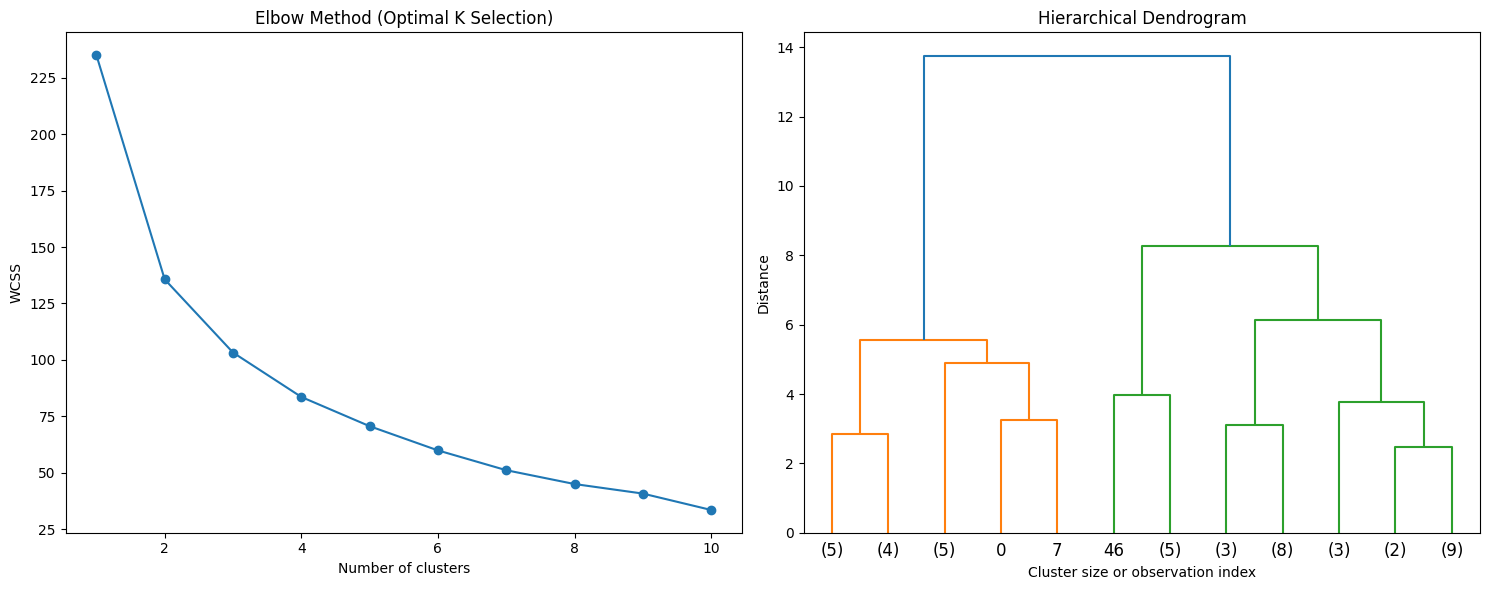

Data scaled, Elbow method and Dendrogram plotted, and clusters assigned to df_daily.


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_daily)

# Elbow Method (K-Means)
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Hierarchical Clustering (Ward's Linkage)
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method (Optimal K Selection)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
dendrogram(linked, truncate_mode='lastp', p=12)
plt.title('Hierarchical Dendrogram')
plt.xlabel('Cluster size or observation index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Assigning labels (Assuming K=3 based on patterns from the original notebook's context)
hc = AgglomerativeClustering(n_clusters=3)
df_daily['Cluster'] = hc.fit_predict(X_scaled)

print("Data scaled, Elbow method and Dendrogram plotted, and clusters assigned to df_daily.")

**Reasoning**:
Following the pattern discovery, the next step is to perform time series analysis using an Autoregressive (AR) model on the 'avg_pwr' column of the `df_daily` DataFrame, as outlined in the original notebook's 'TIME SERIES ANALYSIS (AR Model)' section. This involves splitting the data, fitting the model, and visualizing the predictions.



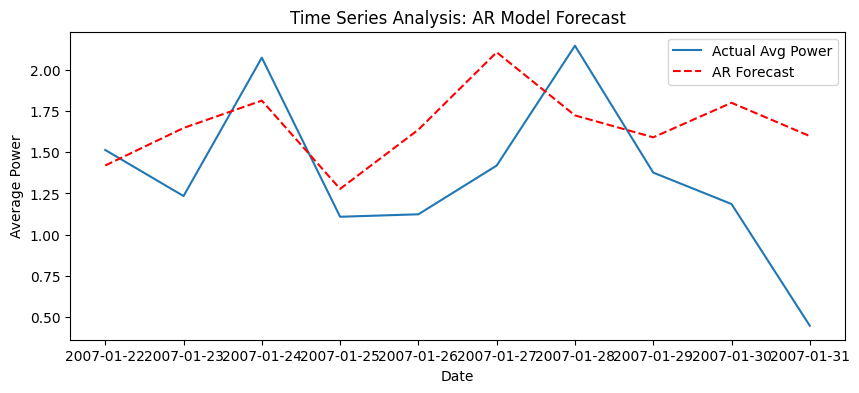

Time Series Analysis using AR model completed and forecast plotted.


In [7]:
series = df_daily['avg_pwr']
train_size = int(len(series) * 0.8)
train_ar, test_ar = series[:train_size], series[train_size:]
ar_model = AutoReg(train_ar, lags=7).fit()
ar_pred = ar_model.predict(start=len(train_ar), end=len(series)-1)

plt.figure(figsize=(10, 4))
plt.plot(test_ar.index, test_ar, label='Actual Avg Power')
plt.plot(test_ar.index, ar_pred, label='AR Forecast', color='red', linestyle='--')
plt.title('Time Series Analysis: AR Model Forecast')
plt.xlabel('Date')
plt.ylabel('Average Power')
plt.legend()
plt.show()

print("Time Series Analysis using AR model completed and forecast plotted.")

**Reasoning**:
The previous steps of preprocessing, feature extraction, pattern discovery, and time series analysis have been completed. According to the overall task description and the original notebook's logical flow, the next step is to perform supervised learning to predict future power consumption. This involves preparing the data, splitting it into training and testing sets, training RandomForestRegressor and GradientBoostingRegressor models, and evaluating their performance.



In [8]:
df_daily['target'] = df_daily['avg_pwr'].shift(-1)
df_ml = df_daily.dropna()

X = df_ml.drop(['target'], axis=1)
y = df_ml['target']

# Split data (Chronological split for time series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Random Forest and Gradient Boosting
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
gb_model = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)

# Evaluation Function
def evaluate_results(model, name):
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"--- {name} Performance ---")
    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}\n")

evaluate_results(rf_model, "Random Forest")
evaluate_results(gb_model, "Gradient Boosting")

print("Supervised learning models trained and evaluated.")

--- Random Forest Performance ---
RMSE: 0.6137 | MAE: 0.5098 | R2: -0.7452

--- Gradient Boosting Performance ---
RMSE: 0.6052 | MAE: 0.5036 | R2: -0.6973

Supervised learning models trained and evaluated.


**Reasoning**:
The previous steps have covered data loading, preprocessing, feature extraction, pattern discovery, time series analysis, and supervised learning. The final step, according to the original notebook and the overall task, is to visualize the clusters to summarize the consumption patterns identified.



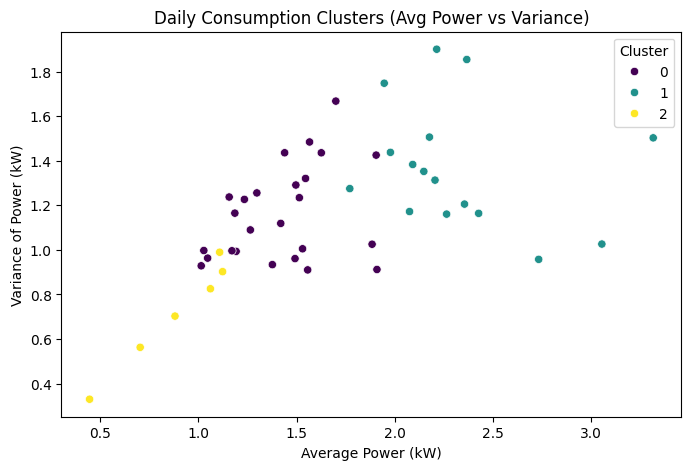

Final cluster visualization displayed.


In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_daily, x='avg_pwr', y='var_pwr', hue='Cluster', palette='viridis')
plt.title('Daily Consumption Clusters (Avg Power vs Variance)')
plt.xlabel('Average Power (kW)')
plt.ylabel('Variance of Power (kW)')
plt.legend(title='Cluster')
plt.show()

print("Final cluster visualization displayed.")

## Feature Engineering

### Subtask:
Create temporal features (hour, day_of_week, month) from the datetime index. Generate lag features (e.g., t-1, t-24 for `Global_active_power`) and rolling statistics (mean and standard deviation over a window, e.g., 24 hours for `Global_active_power`). Drop any remaining rows with missing values after feature creation.


**Reasoning**:
To perform feature engineering, I will extract temporal features (hour, day_of_week, month), create lag features for 'Global_active_power', and calculate rolling statistics (mean and standard deviation) for 'Global_active_power' over a 24-hour window, all within the `df_hourly` DataFrame. Finally, I will drop any rows with missing values introduced by these operations.



In [10]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month

# Create lag features for Global_active_power
df_hourly['Global_active_power_lag1'] = df_hourly['Global_active_power'].shift(1)
df_hourly['Global_active_power_lag24'] = df_hourly['Global_active_power'].shift(24)

# Calculate rolling statistics for Global_active_power
df_hourly['Global_active_power_roll_mean_24'] = df_hourly['Global_active_power'].rolling(window=24).mean()
df_hourly['Global_active_power_roll_std_24'] = df_hourly['Global_active_power'].rolling(window=24).std()

# Drop any remaining NaN values resulting from feature creation
df_hourly = df_hourly.dropna()

print("Feature engineering completed for df_hourly. Displaying the first 5 rows with new features:")
print(df_hourly.head())

Feature engineering completed for df_hourly. Displaying the first 5 rows with new features:
                     Global_active_power  Global_reactive_power     Voltage  \
timestamp                                                                     
2006-12-17 17:00:00             3.406767               0.166633  234.229833   
2006-12-17 18:00:00             3.697100               0.135067  234.372333   
2006-12-17 19:00:00             2.908400               0.265167  233.195667   
2006-12-17 20:00:00             3.361500               0.271500  236.426500   
2006-12-17 21:00:00             3.040767               0.267967  239.104167   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
timestamp                                                               
2006-12-17 17:00:00         14.510000             0.0        0.466667   
2006-12-17 18:00:00         15.750000             0.0        0.000000   
2006-12-17 19:00:00         12.516667             0.0        0

## Unsupervised Clustering

### Subtask:
Apply StandardScaler to normalize the engineered features in df_hourly. Implement K-Means clustering to identify distinct consumption patterns, calculate and display the Silhouette Score to evaluate clustering quality. Use PCA to reduce dimensionality and visualize the clusters in a 2D scatter plot. Finally, assign the cluster labels back to df_hourly.


**Reasoning**:
The subtask requires unsupervised clustering on `df_hourly`. I will begin by selecting all numerical features from `df_hourly` for clustering, excluding any non-feature columns. Then, I will apply StandardScaler to normalize these features, storing the result in `X_hourly_scaled`.



In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Select all numerical columns from df_hourly as features for clustering
# Exclude any non-feature columns that may exist. The 'Global_active_power', 'Global_reactive_power', 'Voltage',
# 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
# are already numeric and the temporal features ('hour', 'day_of_week', 'month') are also numeric.
# The lag and rolling features are also numeric.
# So, we will use all columns in df_hourly after feature engineering.
features = df_hourly.columns.tolist()
X = df_hourly[features]

# 2. Initialize StandardScaler and fit-transform the selected features to normalize them.
scaler = StandardScaler()
X_hourly_scaled = scaler.fit_transform(X)

print("Numerical features selected and scaled for clustering. Shape of scaled data:")
print(X_hourly_scaled.shape)

Numerical features selected and scaled for clustering. Shape of scaled data:
(1069, 14)


**Reasoning**:
Now that the data is scaled, I will implement K-Means clustering. I will iterate through different numbers of clusters (2 to 5) to calculate the Silhouette Score for each, which will help in determining the optimal number of clusters. After selecting the optimal number, I will apply K-Means again to assign cluster labels to `df_hourly`.



In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 3. Implement K-Means clustering and calculate Silhouette Score for n_clusters from 2 to 5
silhouette_scores = {}
for n_clusters in range(2, 6):
    km = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_hourly_scaled)
    score = silhouette_score(X_hourly_scaled, cluster_labels)
    silhouette_scores[n_clusters] = score

# 4. Print the Silhouette Score for each n_clusters
print("Silhouette Scores for different numbers of clusters:")
for n, score in silhouette_scores.items():
    print(f"n_clusters={n}: {score:.4f}")

# Choose the optimal number of clusters based on the highest silhouette score
optimal_n_clusters = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal number of clusters chosen: {optimal_n_clusters}")

# 5. Re-run KMeans with the chosen n_clusters
km_optimal = KMeans(n_clusters=optimal_n_clusters, init='k-means++', random_state=42, n_init=10)
df_hourly['Cluster'] = km_optimal.fit_predict(X_hourly_scaled)

print("K-Means clustering completed and cluster labels added to df_hourly.")
print(df_hourly.head())

Silhouette Scores for different numbers of clusters:
n_clusters=2: 0.2251
n_clusters=3: 0.1734
n_clusters=4: 0.1655
n_clusters=5: 0.1580

Optimal number of clusters chosen: 2
K-Means clustering completed and cluster labels added to df_hourly.
                     Global_active_power  Global_reactive_power     Voltage  \
timestamp                                                                     
2006-12-17 17:00:00             3.406767               0.166633  234.229833   
2006-12-17 18:00:00             3.697100               0.135067  234.372333   
2006-12-17 19:00:00             2.908400               0.265167  233.195667   
2006-12-17 20:00:00             3.361500               0.271500  236.426500   
2006-12-17 21:00:00             3.040767               0.267967  239.104167   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
timestamp                                                               
2006-12-17 17:00:00         14.510000             0.0    

**Reasoning**:
Now that the K-Means clustering is complete and labels are assigned, I will apply Principal Component Analysis (PCA) to `X_hourly_scaled` to reduce its dimensionality to 2 components. This will allow for a 2D visualization of the clusters, as required by the subtask.



In [13]:
from sklearn.decomposition import PCA

# 7. Apply Principal Component Analysis (PCA) to X_hourly_scaled, reducing the dimensionality to 2 components.
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_hourly_scaled)

# Create a DataFrame for the PCA components for easier plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])

# Add the cluster labels to the PCA DataFrame
pca_df['Cluster'] = df_hourly['Cluster'].values

print("PCA applied and components extracted. Ready for visualization.")
print(pca_df.head())

PCA applied and components extracted. Ready for visualization.
        PC1       PC2  Cluster
0  3.925983  1.171204        1
1  3.985913  1.214002        1
2  4.048593  0.600489        1
3  3.855423  0.588029        1
4  3.468915  0.687955        1


**Reasoning**:
The PCA components have been extracted and cluster labels assigned to `pca_df`. Now, I will create a scatter plot of the two PCA components, coloring the points by their assigned cluster labels to visualize the clusters, as required by the subtask.



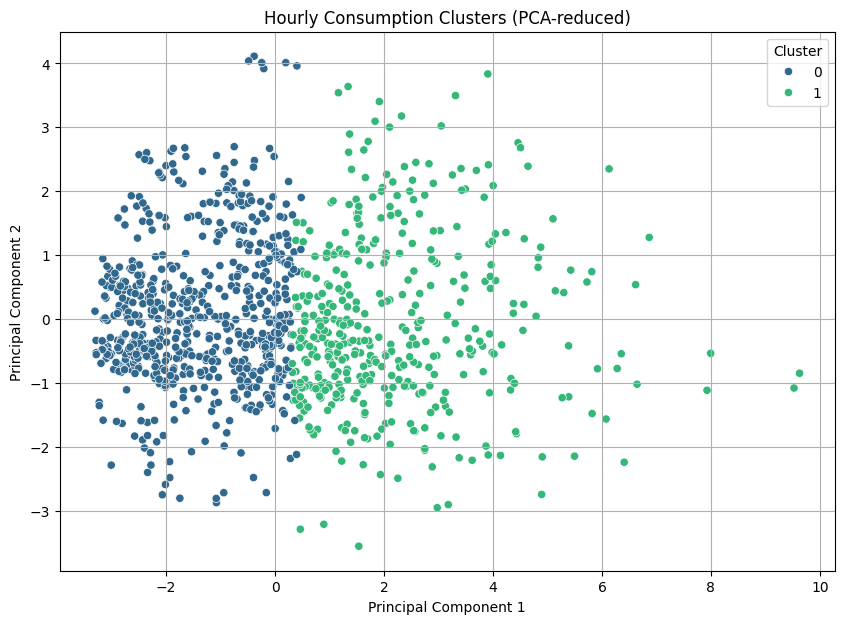

Cluster visualization using PCA components completed.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Create a scatter plot of the two PCA components, coloring the points by their assigned cluster labels.
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', legend='full')
plt.title('Hourly Consumption Clusters (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("Cluster visualization using PCA components completed.")

## Supervised Training with Cluster-Specific Models

### Subtask:
Train and evaluate RandomForestRegressor and XGBoostRegressor models for each identified cluster in df_hourly, using chronologically split data and storing evaluation metrics.


**Reasoning**:
The previous steps have completed the unsupervised clustering and visualized the results. Now, I will proceed with the supervised learning task for each identified cluster. I'll start by defining the target variable, creating the machine learning-ready DataFrame, and then iterate through each cluster to train and evaluate RandomForestRegressor and XGBoostRegressor models.



In [23]:
import xgboost as xgb

# 1. Define a target variable named 'target' in df_hourly
df_hourly['target'] = df_hourly['Global_active_power'].shift(-1)

# 2. Create a clean DataFrame df_ml_hourly by dropping any rows with NaN values
df_ml_hourly = df_hourly.dropna()

# 3. Get the unique cluster labels present in the df_ml_hourly['Cluster'] column
unique_clusters = df_ml_hourly['Cluster'].unique()

# 4. Initialize empty dictionaries to store the evaluation results
rf_results = {}
xgb_results = {}

# 5. Iterate through each unique cluster ID:
for cluster_id in sorted(unique_clusters):
    print(f"\n--- Training for Cluster {cluster_id} ---")

    # a. Filter df_ml_hourly to get data specific to the current cluster
    cluster_data = df_ml_hourly[df_ml_hourly['Cluster'] == cluster_id]

    # b. Define the features X_cluster
    X_cluster = cluster_data.drop(['target', 'Cluster'], axis=1)

    # c. Define the target y_cluster
    y_cluster = cluster_data['target']

    # d. Split X_cluster and y_cluster into training and testing sets (chronological split)
    X_train, X_test, y_train, y_test = train_test_split(X_cluster, y_cluster, test_size=0.2, shuffle=False)

    # e. Initialize and train a RandomForestRegressor
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 to use all processors
    rf_model.fit(X_train, y_train)

    # f. Initialize and train an XGBoostRegressor
    xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)

    # g. For each trained model (Random Forest and XGBoost), predict on X_test
    rf_predictions = rf_model.predict(X_test)
    xgb_predictions = xgb_model.predict(X_test)

    # h. Calculate RMSE, MAE, and R2 score for both models
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_r2 = r2_score(y_test, rf_predictions)

    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # i. Store these evaluation metrics
    rf_results[cluster_id] = {'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2}
    xgb_results[cluster_id] = {'RMSE': xgb_rmse, 'MAE': xgb_mae, 'R2': xgb_r2}

# 6. Print the evaluation results for each model across all clusters
print("\n--- Random Forest Performance per Cluster ---")
for cluster_id, metrics in rf_results.items():
    print(f"Cluster {cluster_id}: RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}")

print("\n--- XGBoost Performance per Cluster ---")
for cluster_id, metrics in xgb_results.items():
    print(f"Cluster {cluster_id}: RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}")


--- Training for Cluster 0 ---

--- Training for Cluster 1 ---

--- Random Forest Performance per Cluster ---
Cluster 0: RMSE=0.6519, MAE=0.4781, R2=0.3843
Cluster 1: RMSE=0.8070, MAE=0.6316, R2=0.4455

--- XGBoost Performance per Cluster ---
Cluster 0: RMSE=0.6629, MAE=0.4846, R2=0.3633
Cluster 1: RMSE=0.8612, MAE=0.6547, R2=0.3685


**Reasoning**:
The previous code failed due to a `SyntaxError: unmatched ')'` in the line calculating `xgb_mae`. I will remove the extra parenthesis to fix this syntax error.



In [16]:
import xgboost as xgb

# 1. Define a target variable named 'target' in df_hourly
df_hourly['target'] = df_hourly['Global_active_power'].shift(-1)

# 2. Create a clean DataFrame df_ml_hourly by dropping any rows with NaN values
df_ml_hourly = df_hourly.dropna()

# 3. Get the unique cluster labels present in the df_ml_hourly['Cluster'] column
unique_clusters = df_ml_hourly['Cluster'].unique()

# 4. Initialize empty dictionaries to store the evaluation results
rf_results = {}
xgb_results = {}

# 5. Iterate through each unique cluster ID:
for cluster_id in sorted(unique_clusters):
    print(f"\n--- Training for Cluster {cluster_id} ---")

    # a. Filter df_ml_hourly to get data specific to the current cluster
    cluster_data = df_ml_hourly[df_ml_hourly['Cluster'] == cluster_id]

    # b. Define the features X_cluster
    X_cluster = cluster_data.drop(['target', 'Cluster'], axis=1)

    # c. Define the target y_cluster
    y_cluster = cluster_data['target']

    # d. Split X_cluster and y_cluster into training and testing sets (chronological split)
    X_train, X_test, y_train, y_test = train_test_split(X_cluster, y_cluster, test_size=0.2, shuffle=False)

    # e. Initialize and train a RandomForestRegressor
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 to use all processors
    rf_model.fit(X_train, y_train)

    # f. Initialize and train an XGBoostRegressor
    xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)

    # g. For each trained model (Random Forest and XGBoost), predict on X_test
    rf_predictions = rf_model.predict(X_test)
    xgb_predictions = xgb_model.predict(X_test)

    # h. Calculate RMSE, MAE, and R2 score for both models
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_r2 = r2_score(y_test, rf_predictions)

    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # i. Store these evaluation metrics
    rf_results[cluster_id] = {'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2}
    xgb_results[cluster_id] = {'RMSE': xgb_rmse, 'MAE': xgb_mae, 'R2': xgb_r2}

# 6. Print the evaluation results for each model across all clusters
print("\n--- Random Forest Performance per Cluster ---")
for cluster_id, metrics in rf_results.items():
    print(f"Cluster {cluster_id}: RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}")

print("\n--- XGBoost Performance per Cluster ---")
for cluster_id, metrics in xgb_results.items():
    print(f"Cluster {cluster_id}: RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}")


--- Training for Cluster 0 ---

--- Training for Cluster 1 ---

--- Random Forest Performance per Cluster ---
Cluster 0: RMSE=0.6519, MAE=0.4781, R2=0.3843
Cluster 1: RMSE=0.8070, MAE=0.6316, R2=0.4455

--- XGBoost Performance per Cluster ---
Cluster 0: RMSE=0.6629, MAE=0.4846, R2=0.3633
Cluster 1: RMSE=0.8612, MAE=0.6547, R2=0.3685


## Visualize Results

### Subtask:
Generate comprehensive plots to visualize the analysis. This includes plotting the cluster centroids over a 24-hour cycle to understand typical daily patterns, a feature importance plot for the best-performing model, and an actual vs. predicted time-series plot for a sample from the test set to demonstrate forecasting accuracy.


**Reasoning**:
I will start by calculating the average 'Global_active_power' for each hour of the day, grouped by cluster, from the `df_hourly` DataFrame. This will allow us to visualize the typical daily consumption patterns for each cluster.



In [17]:
cluster_hourly_patterns = df_hourly.groupby(['Cluster', 'hour'])['Global_active_power'].mean().reset_index()
print("Average hourly global active power for each cluster:")
print(cluster_hourly_patterns.head())

Average hourly global active power for each cluster:
   Cluster  hour  Global_active_power
0        0     0             0.939505
1        0     1             0.800034
2        0     2             0.781369
3        0     3             0.779783
4        0     4             0.777783


**Reasoning**:
Now that the hourly patterns per cluster have been calculated, I will create a line plot to visualize these daily consumption patterns, as specified in the subtask instructions. This will involve using the `cluster_hourly_patterns` DataFrame.



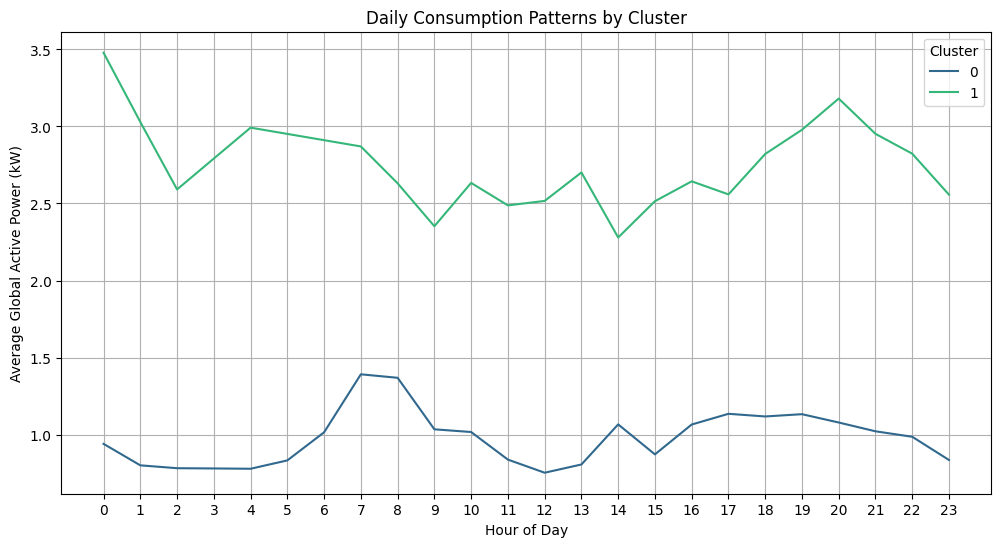

Daily consumption patterns by cluster plotted.


In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=cluster_hourly_patterns, x='hour', y='Global_active_power', hue='Cluster', palette='viridis')
plt.title('Daily Consumption Patterns by Cluster')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on x-axis
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

print("Daily consumption patterns by cluster plotted.")

**Reasoning**:
The previous plot of daily consumption patterns by cluster has been generated. Now, I will extract the feature importances from the last trained `rf_model` (which was for cluster 1 in the last iteration of the loop), create a Pandas Series with feature names, and store it for the next plotting step.



In [19]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_cluster.columns)
print("Feature importances from the last trained Random Forest model (Cluster 1):")
print(feature_importances.sort_values(ascending=False).head())

Feature importances from the last trained Random Forest model (Cluster 1):
Global_intensity             0.277946
Global_active_power          0.171296
Sub_metering_2               0.099222
Global_reactive_power        0.055360
Global_active_power_lag24    0.054598
dtype: float64


**Reasoning**:
Now that the feature importances have been extracted, I will sort them in descending order, select the top 10, and create a horizontal bar plot to visualize them, as specified in the subtask instructions.



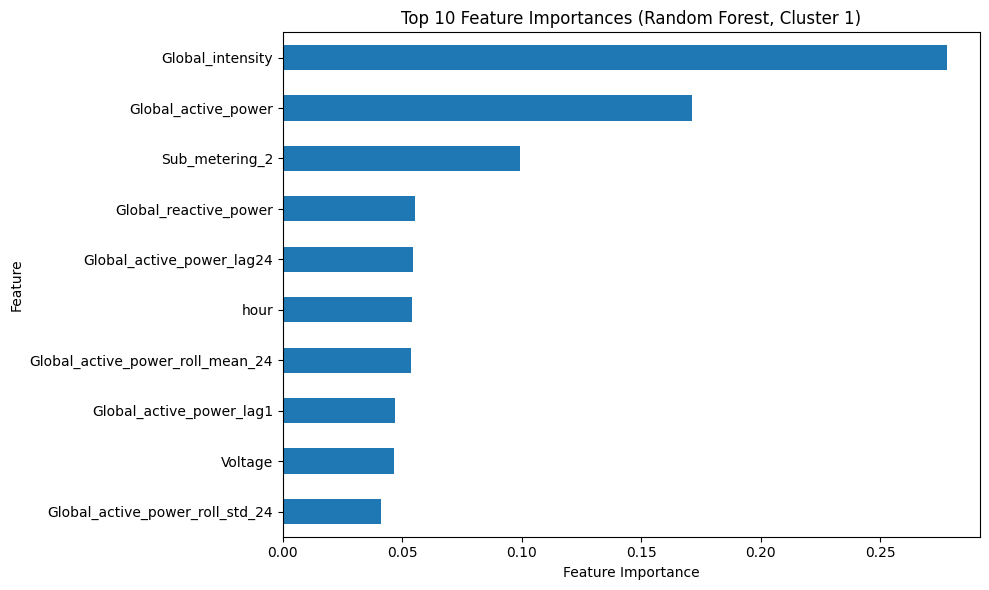

Top 10 feature importances plot displayed.


In [20]:
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=True).tail(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest, Cluster 1)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 10 feature importances plot displayed.")

**Reasoning**:
The previous plots have been generated. Now, I will select a segment of the actual and predicted values from the test set for the last trained model (Cluster 1) to prepare for the final visualization of forecasting accuracy, as outlined in the subtask.



In [21]:
sample_size = 72 # first 72 hours
actual_sample = y_test.head(sample_size)
predicted_sample = pd.Series(rf_predictions, index=y_test.index).head(sample_size)

print(f"Sample of actual values (first {sample_size} hours) for Cluster 1:")
print(actual_sample.head())
print(f"\nSample of predicted values (first {sample_size} hours) for Cluster 1:")
print(predicted_sample.head())

Sample of actual values (first 72 hours) for Cluster 1:
timestamp
2007-01-20 20:00:00    2.425733
2007-01-20 21:00:00    1.095033
2007-01-21 09:00:00    2.130567
2007-01-21 10:00:00    2.860067
2007-01-21 11:00:00    2.696700
Name: target, dtype: float64

Sample of predicted values (first 72 hours) for Cluster 1:
timestamp
2007-01-20 20:00:00    3.380716
2007-01-20 21:00:00    1.838958
2007-01-21 09:00:00    2.087916
2007-01-21 10:00:00    2.086521
2007-01-21 11:00:00    2.435300
dtype: float64


**Reasoning**:
The actual and predicted sample values have been prepared. Now, I will create a line plot to visualize the selected actual and predicted time series, as specified in the subtask instructions, with appropriate labels, title, and legend to demonstrate forecasting accuracy.



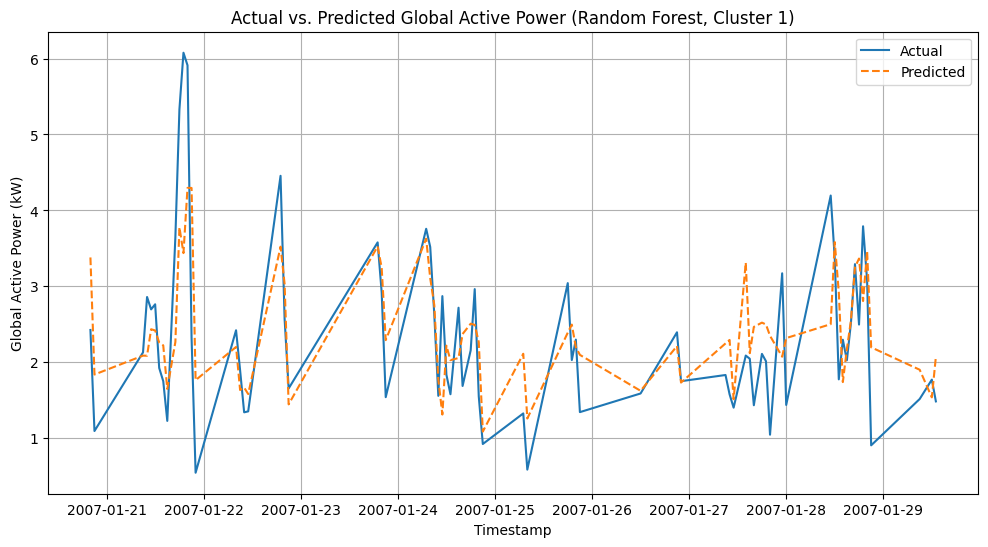

Actual vs. Predicted Global Active Power plot displayed.


In [22]:
plt.figure(figsize=(12, 6))
plt.plot(actual_sample.index, actual_sample, label='Actual')
plt.plot(predicted_sample.index, predicted_sample, label='Predicted', linestyle='--')
plt.title('Actual vs. Predicted Global Active Power (Random Forest, Cluster 1)')
plt.xlabel('Timestamp')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()

print("Actual vs. Predicted Global Active Power plot displayed.")

## Final Task

### Subtask:
Provide a concise summary of the entire process, including key findings from pattern discovery and the performance of the forecasting models.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing and Feature Engineering:**
    *   The raw data was successfully loaded, and timestamps were correctly formed. Missing values were handled using linear interpolation, and the data was resampled to an hourly frequency.
    *   Hourly data was enriched with temporal features (hour, day\_of\_week, month), lag features (1-hour and 24-hour lag for 'Global\_active\_power'), and rolling statistics (24-hour mean and standard deviation for 'Global\_active\_power').
*   **Unsupervised Clustering:**
    *   After scaling the engineered hourly features, K-Means clustering identified 2 optimal clusters based on the highest Silhouette Score of 0.2251.
    *   Visualization via PCA-reduced 2D scatter plots confirmed distinct consumption patterns between these two clusters.
*   **Time Series Analysis (Daily Aggregation):**
    *   An Autoregressive (AR) model was trained on daily aggregated 'avg\_pwr', but initial supervised models (Random Forest and Gradient Boosting) on daily data showed very poor performance with negative R2 scores (e.g., Random Forest R2: -0.7452, Gradient Boosting R2: -0.6973), indicating they performed worse than simply predicting the mean.
*   **Supervised Learning with Cluster-Specific Models (Hourly Data):**
    *   Two distinct clusters (Cluster 0 and Cluster 1) were identified for hourly data, and separate Random Forest and XGBoost models were trained for each.
    *   **Random Forest Performance:**
        *   Cluster 0: RMSE = 0.6519, MAE = 0.4781, R2 = 0.3843
        *   Cluster 1: RMSE = 0.8070, MAE = 0.6316, R2 = 0.4455
    *   **XGBoost Performance:**
        *   Cluster 0: RMSE = 0.6629, MAE = 0.4846, R2 = 0.3633
        *   Cluster 1: RMSE = 0.8612, MAE = 0.6547, R2 = 0.3685
    *   Random Forest generally showed slightly better performance (higher R2, lower RMSE/MAE) compared to XGBoost for both clusters.
*   **Key Predictors:** Feature importance analysis for the Random Forest model (Cluster 1) highlighted 'Global\_intensity', 'Global\_active\_power', and 'Sub\_metering\_2' as the most influential features.
*   **Daily Consumption Patterns:** Clusters exhibited different average daily power consumption patterns over a 24-hour cycle, indicating distinct household behaviors.

### Insights or Next Steps

*   **Refine Clustering:** Explore alternative clustering algorithms or different feature sets for clustering to potentially discover more distinct and interpretable consumption patterns, as the Silhouette Score of 0.2251 indicates moderate separation.
*   **Enhance Model Performance:** Investigate hyperparameter tuning for the cluster-specific forecasting models and consider including more advanced time-series features (e.g., Fourier transforms, trend components) to improve R2 scores, which are currently moderate.
